# Task 2

In this task you will implement a multi-layer perceptron (MLP) for classification, the
finite-differences approach for approximately computing the gradient of the loss with
respect to the weights of the MLP, and train the MLP using the Adam optimizer (which
is a variant of SGD that uses individual learning rates for each parameter).

In [9]:
import h5py
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from _stochastic_optimizers import AdamOptimizer
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

## Subtask 1: Classification Data

In [2]:
hf = h5py.File('D:/My_ML/UniWien/intro_to_ML/data/classification.h5', 'r')
x_train = np.array(hf.get('x_train'))
y_train = np.array(hf.get('y_train'))
x_test = np.array(hf.get('x_test'))
y_test = np.array(hf.get('y_test'))
hf.close()


In [3]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Dataset statistics**

In [ ]:
print("1 Feature STATISTICS")
print(f"Number of features: {x_train.shape[1]}")
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Total samples: {x_train.shape[0] + x_test.shape[0]}")   
print("2 TARGET STATISTICS")
print(f"Unique values in y_train: {np.unique(y_train.shape[0])}")
print(f"Unique values in y_test: {np.unique(y_test.shape[0])}")
print("3 CLASS DISTRIBUTION")
print(f"Training set: {y_train.shape[0]} samples with {y_train.shape[1]} classes each")
print(f"Test set: {y_test.shape[0]} samples with {y_test.shape[1]} classes each")

1 Feature STATISTICS
   Number of features: 2
   Training samples: 500
   Test samples: 10000
   Total samples: 10500
2 TARGET STATISTICS
   Unique values in y_train: [500]
   Unique values in y_test: [10000]
3 CLASS DISTRIBUTION
   Training set: 500 samples with 1 classes each
   Test set: 10000 samples with 1 classes each


## Subtask 2: Forward Propagation

In [5]:
class CustomMLP:
    def __init__(self, layer_sizes, activation='relu', seed=42):
        """
        Init of the MLP
        Parameters:
        layer_sizes : list
            List of layers size [input_size, hidden1_size, ..., output_size]
        activation : str
           Activation function ('relu', 'sigmoid', 'tanh')
        """
        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.weights = []
        self.biases = []
        
        # Initialization of weights and biases
        np.random.seed(seed)
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i+1]))
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale
            b = np.zeros((1, layer_sizes[i+1]))
        
            self.weights.append(W)
            self.biases.append(b)
    
    def _activation(self, x):
        if self.activation_name == 'relu':
            return np.maximum(0, x)
        elif self.activation_name == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        elif self.activation_name == 'tanh':
            return np.tanh(x)
    
    def forward(self, x):
        if len(x.shape) == 1:
            x = x.reshape(1, -1)
        
        outputs = [x]
        current = x
        for i in range(len(self.weights) - 1):
            z = np.dot(current, self.weights[i]) + self.biases[i]
            a = self._activation(z)
            outputs.append(z)  # linear output
            outputs.append(a)  # output after activation
            current = a
        # Output layer without activation
        z_final = np.dot(current, self.weights[-1]) + self.biases[-1]
        outputs.append(z_final)
        
        return outputs
    
    def predict(self, x):
        #Prediction for input data
        outputs = self.forward(x)
        return outputs[-1]
    
    def get_parameters(self):
        # Get all model parametrs as list
        params = []
        for W, b in zip(self.weights, self.biases):
            params.append(W.flatten())
            params.append(b.flatten())
        return np.concatenate(params)
    
    def set_parameters(self, flat_params):
        #Set model parametrs from a list
        idx = 0
        for i in range(len(self.weights)):
            W_size = self.weights[i].size
            b_size = self.biases[i].size
            self.weights[i] = flat_params[idx:idx+W_size].reshape(self.weights[i].shape)
            idx += W_size
            self.biases[i] = flat_params[idx:idx+b_size].reshape(self.biases[i].shape)
            idx += b_size

In this implemetation the class CustomMLP consist of several functions. The init() function initializez the weights matrix W (using random Glorot (tanh) initialization) and the biases vector b as zeros.
Then activation functions Relu, Sigmoid and Tanh are defined via numpy mathematical functions. After that forward propagation is implemented according to lecture slides.
The weigths and biases are stored as Class attributes as arrays.

## Subtask 3: Finite Difference Gradient & Optimization

In [ ]:
def hinge_loss(predictions, targets):
    # Hinge loss function for classification task
    # Resccaling targets {-1, 1}
    y_binary = 2 * targets - 1  # targets ∈ {0, 1}
    y_binary = y_binary.reshape(-1, 1)
    
    # Hinge loss
    loss = np.maximum(0, 1 - y_binary * predictions)
    return np.mean(loss)

def finite_difference_gradient(model, x, y, epsilon=1e-5):
    # Gradient calculation with finite defferences method
    # Save the original params
    original_params = model.get_parameters()
    # Initialize lists for the gradients
    grad_weights = [np.zeros_like(W) for W in model.weights]
    grad_biases = [np.zeros_like(b) for b in model.biases]
    # Calculating the original loss function
    pred_original = model.predict(x)
    loss_original = hinge_loss(pred_original, y)
    
    # Calculating the gradients for each patametr 
    param_idx = 0
    for layer_idx in range(len(model.weights)):
        # Gradient on weights
        W = model.weights[layer_idx]
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                # Recover the orinila params
                model.set_parameters(original_params)
                # W + epsilon
                model.weights[layer_idx][i, j] += epsilon
                pred_plus = model.predict(x)
                loss_plus = hinge_loss(pred_plus, y)
                # W - epsilon
                model.set_parameters(original_params)
                model.weights[layer_idx][i, j] -= epsilon
                pred_minus = model.predict(x)
                loss_minus = hinge_loss(pred_minus, y)
                # Gradient approximation
                grad_weights[layer_idx][i, j] = (loss_plus - loss_minus) / (2 * epsilon)
        
        # Gradient for biases
        b = model.biases[layer_idx]
        for i in range(b.shape[1]):
            # Recover of original params
            model.set_parameters(original_params)
            # b + epsilon
            model.biases[layer_idx][0, i] += epsilon
            pred_plus = model.predict(x)
            loss_plus = hinge_loss(pred_plus, y)
            # b - epsilon
            model.set_parameters(original_params)
            model.biases[layer_idx][0, i] -= epsilon
            pred_minus = model.predict(x)
            loss_minus = hinge_loss(pred_minus, y)
            # Gradient approximation
            grad_biases[layer_idx][0, i] = (loss_plus - loss_minus) / (2 * epsilon)
    # Recover of original params
    model.set_parameters(original_params)
    return grad_weights, grad_biases

def train_with_finite_differences(x_train, y_train, x_test, y_test, layer_sizes, activation='relu', epochs=100, lr=0.001, batch_size=32):
    # Model training using finite_difference_gradient
    model = CustomMLP(layer_sizes, activation=activation)
    #initializing the Adam optimizer
    all_params = []
    for i in range(len(model.weights)):
        all_params.append(model.weights[i])   # weights
        all_params.append(model.biases[i])
    optimizer = AdamOptimizer(all_params, lr, 0.9, 0.999, 1e-08)
    # For history of training
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    n_samples = x_train.shape[0]
    print(f"Training MLP with architecture: {layer_sizes}, activation: {activation}")
    start_time = time.time()
    
    for epoch in range(epochs):
        # Data permutation
        indices = np.random.permutation(n_samples)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train[indices]
        epoch_loss = 0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            x_batch = x_train_shuffled[i:batch_end]
            y_batch = y_train_shuffled[i:batch_end]
            
            # Gradient calculations
            grad_weights, grad_biases = finite_difference_gradient(model, x_batch, y_batch)
            all_grads = []
            for j in range(len(grad_weights)):
                all_grads.append(grad_weights[j])   # gradient for weights
                all_grads.append(grad_biases[j])    # gradient for biases
            
            # update the parameters
            optimizer.update_params(all_params, all_grads)
            # After update with optimizer we need to update the model parameters
            for j in range(len(model.weights)):
                model.weights[j] = all_params[2*j].copy()
                model.biases[j] = all_params[2*j + 1].copy()
            # Loss calc
            pred_batch = model.predict(x_batch)
            batch_loss = hinge_loss(pred_batch, y_batch)
            epoch_loss += batch_loss
            n_batches += 1
        
        # Avarage loss in epoch
        avg_train_loss = epoch_loss / n_batches if n_batches > 0 else 0
        # Make predictions
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)
        train_loss = hinge_loss(train_pred, y_train)
        test_loss = hinge_loss(test_pred, y_test)
        
        # Accuracy calculation
        train_acc = np.mean((train_pred > 0).astype(int).flatten() == y_train)
        test_acc = np.mean((test_pred > 0).astype(int).flatten() == y_test)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}, "
                  f"Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    
    return model, train_losses, test_losses, train_accs, test_accs, training_time

In [ ]:
input_size = x_train.shape[1]
arch1_layer_sizes = [input_size, 10, 10, 1] 
print("Architecture 1: [input, 10, 10, 1] with ReLU")
model1, train_loss1, test_loss1, train_acc1, test_acc1, time1 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
    layer_sizes=arch1_layer_sizes, activation='relu',
    epochs=50, lr=0.001, batch_size=32)
    
arch2_layer_sizes = [input_size, 20, 10, 1]
print("Architecture 2: [input, 20, 10, 1] with Sigmoid")
model2, train_loss2, test_loss2, train_acc2, test_acc2, time2 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
        layer_sizes=arch2_layer_sizes, activation='sigmoid',
        epochs=50, lr=0.001, batch_size=32)

arch3_layer_sizes = [input_size, 30, 15, 1]
print("Architecture 3: [input, 30, 15, 1] with ReLU")
model3, train_loss3, test_loss3, train_acc3, test_acc3, time3 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
        layer_sizes=arch2_layer_sizes, activation='relu',
        epochs=50, lr=0.001, batch_size=32)


--- Architecture 1: [input, 10, 10, 1] with ReLU ---
Training MLP with architecture: [2, 10, 10, 1], activation: relu
Epoch 0: Train Loss = 0.9196, Test Loss = 0.9575, Train Acc = 0.5120, Test Acc = 0.5158
Epoch 10: Train Loss = 0.8303, Test Loss = 0.9026, Train Acc = 0.5014, Test Acc = 0.5023
Epoch 20: Train Loss = 0.7633, Test Loss = 0.8747, Train Acc = 0.5006, Test Acc = 0.5010
Epoch 30: Train Loss = 0.7557, Test Loss = 0.8714, Train Acc = 0.5007, Test Acc = 0.5011
Epoch 40: Train Loss = 0.7524, Test Loss = 0.8674, Train Acc = 0.5003, Test Acc = 0.5004
Training completed in 30.15 seconds

--- Architecture 2: [input, 20, 10, 1] with Sigmoid ---
Training MLP with architecture: [2, 20, 10, 1], activation: sigmoid
Epoch 0: Train Loss = 1.0125, Test Loss = 1.0098, Train Acc = 0.4903, Test Acc = 0.4868
Epoch 10: Train Loss = 0.9172, Test Loss = 0.9439, Train Acc = 0.5045, Test Acc = 0.5065
Epoch 20: Train Loss = 0.7667, Test Loss = 0.8594, Train Acc = 0.5023, Test Acc = 0.5036
Epoch 30: 

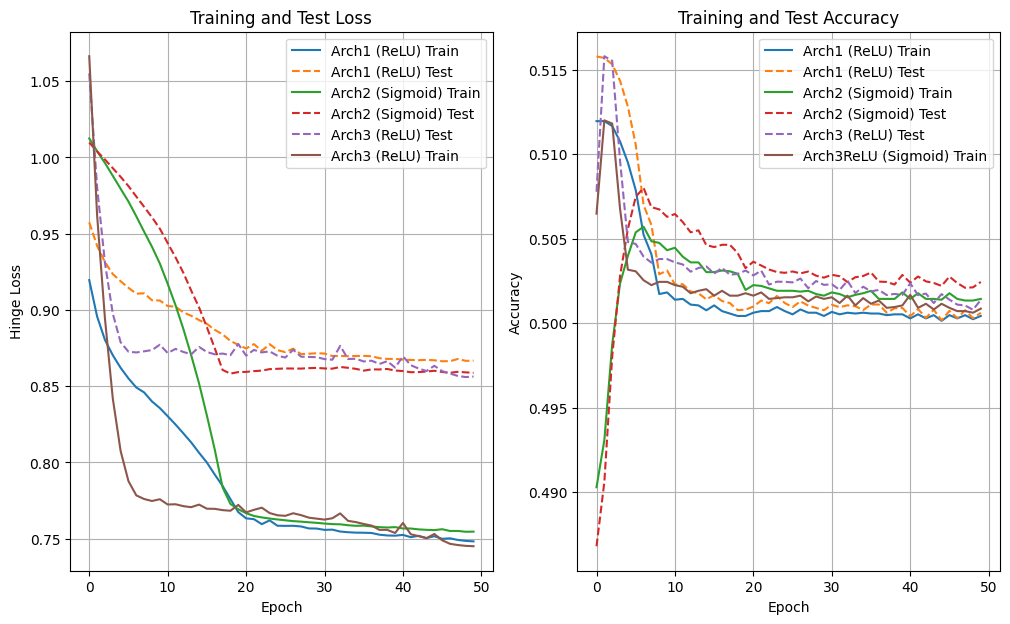

In [8]:
# Result visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    
axes[0].plot(train_loss1, label='Arch1 (ReLU) Train')
axes[0].plot(test_loss1, label='Arch1 (ReLU) Test', linestyle='--')
axes[0].plot(train_loss2, label='Arch2 (Sigmoid) Train')
axes[0].plot(test_loss2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[0].plot(test_loss3, label='Arch3 (ReLU) Test', linestyle='--')
axes[0].plot(train_loss3, label='Arch3 (ReLU) Train')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Hinge Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(train_acc1, label='Arch1 (ReLU) Train')
axes[1].plot(test_acc1, label='Arch1 (ReLU) Test', linestyle='--')
axes[1].plot(train_acc2, label='Arch2 (Sigmoid) Train')
axes[1].plot(test_acc2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[1].plot(test_acc3, label='Arch3 (ReLU) Test', linestyle='--')
axes[1].plot(train_acc3, label='Arch3ReLU (Sigmoid) Train')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

At first the time for training can be observed. It is obvious that for models with more neurons the time will be bigger. However, the time for architecture 2 with sigmoid activation function has time 59 sec. which is more than for model with architecture 3 with ReLU (45 sec.) despite that Architecture 3 has more neurons.
And for the Hinge Loss function, the Architecture 3 has more rapid recrease of loss. One more distinction is that model with sigmoid activation function is more smooth that models with ReLU.
In the loss there is no big difference between models. However, according to accuracy plot architecture 1 with ReLU and less neurons perform better than other models.

## Subtask 4: Model training using PyTorch

In [ ]:
class PyTorchMLP(nn.Module):
# class for implemetation of MLP using PyTorch
    
    def __init__(self, layer_sizes, activation='relu'):
        # initialisation function
        super(PyTorchMLP, self).__init__()
        
        # Save the architecture params
        self.input_size = layer_sizes[0]
        self.hidden_sizes = layer_sizes[1:2]
        self.activation_type = activation
        
        # Layers
        self.layer1 = nn.Linear(layer_sizes[0], layer_sizes[1])
        self.layer2 = nn.Linear(layer_sizes[1], layer_sizes[2])
        self.output = nn.Linear(layer_sizes[2], 1)
        
        # Activation functions
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        
        # Weights initialisation
        self._initialize_weights()
    
    def _initialize_weights(self):
        #function for weights initialisation
        # for each layer using randomly uniformed init
        for layer in [self.layer1, self.layer2, self.output]:
            nn.init.xavier_uniform_(layer.weight)
            # initialisation of biases
            nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        #Forward propagation
        # Layer1
        x = self.layer1(x)
        x = self.activation(x)
        # Hidden layer
        x = self.layer2(x)
        x = self.activation(x)
        # Output layer
        x = self.output(x)
        x = torch.tanh(x) #* 0.5
        return x
    
    def predict_proba(self, x):
        # probability prediction
        with torch.no_grad():
            logits = self.forward(x)
            probabilities = torch.sigmoid(logits)
            return probabilities.cpu().numpy()
    
    def predict(self, x):
        # class prediction function
        with torch.no_grad():
            logits = self.forward(x)
            # Binary classification
            predictions = (logits > 0).float()
            return predictions.cpu().numpy()
    
    def get_architecture_info(self):
        # get architecture information
        return {
            'input_size': self.input_size,
            'hidden_sizes': self.hidden_sizes,
            'activation': self.activation_type,
            'total_params': sum(p.numel() for p in self.parameters())
        }


def compute_accuracy(model, x_tensor, y_true_binary):
    #function for computation of accuracy with sklearn
    model.eval()
    with torch.no_grad():
        y_pred = model.predict(x_tensor) 
        accuracy = accuracy_score(y_true_binary, y_pred)
        return accuracy


def train_pytorch_model_with_sklearn_metrics(x_train, y_train_torch, x_test, y_test_torch,
                                            y_train_binary, y_test_binary, layer_sizes, activation,
                                            epochs=100, lr=0.001, batch_size=32):
    #training function for MLP with PyTorch
    model = PyTorchMLP(
        layer_sizes=layer_sizes,  
        activation= activation
    )
    model.train()
    # Optimizer Adam (PyTorch)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.HingeEmbeddingLoss(margin=1.0)
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = [] 
    n_samples = x_train.shape[0]
    start_time = time.time()
    
    for epoch in range(epochs):
        # Mix the data
        permutation = torch.randperm(n_samples)
        epoch_train_loss = 0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x = x_train[indices]
            batch_y = y_train_torch[indices]

            optimizer.zero_grad() # Set gradients to zero
            outputs = model(batch_x) # Forward pass
            loss = criterion(outputs, batch_y) # Calculate loss
            loss.backward() # Backward pass
            optimizer.step() # Update the params
            epoch_train_loss += loss.item()
            n_batches += 1
        
        # Evaluation
        model.eval()
        with torch.no_grad():
            train_outputs = model(x_train)
            train_loss = criterion(train_outputs, y_train_torch).item()
            test_outputs = model(x_test)
            test_loss = criterion(test_outputs, y_test_torch).item()
            y_pred_train = model.predict(x_train) 
            train_accuracy = accuracy_score(y_train_binary, y_pred_train)
            y_pred_test = model.predict(x_test) 
            test_accuracy = accuracy_score(y_test_binary, y_pred_test)
       
        # Save metrics
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        
        # Progress output
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}/{epochs}: "
                  f"Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}, "
                  f"Train Acc = {train_accuracy:.4f}, Test Acc = {test_accuracy:.4f}")
        
        model.train()
    
    training_time = time.time() - start_time
    print(f"Training complete in {training_time:.2f} seconds")
    
    # Final eval
    model.eval()
    with torch.no_grad():
        y_pred_train = model.predict(x_train) 
        train_accuracy = accuracy_score(y_train_binary, y_pred_train)
        y_pred_test = model.predict(x_test) 
        test_accuracy = accuracy_score(y_test_binary, y_pred_test)
    
    print(f"Final accuracy")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:  {test_accuracy:.4f}")
    
    return model, train_losses, test_losses, train_accuracies, test_accuracies, training_time


In [ ]:
y_train_binary = y_train.copy()
y_test_binary = y_test.copy()
y_train_torch = torch.FloatTensor(2 * y_train_binary - 1).view(-1, 1)
y_test_torch = torch.FloatTensor(2 * y_test_binary - 1).view(-1, 1)
x_train_tensor = torch.FloatTensor(x_train)
x_test_tensor = torch.FloatTensor(x_test)
input_size = x_train.shape[1]
print("MLP with PyTorch")

arch1_layer_sizes = [input_size, 10, 10, 1] 
print("Architecture 1: [input, 10, 10, 1] with ReLU")
model1, train_loss1, test_loss1, train_acc1, test_acc1, time1 = train_pytorch_model_with_sklearn_metrics(
        x_train=x_train_tensor,
        y_train_torch=y_train_torch,
        x_test=x_test_tensor,
        y_test_torch=y_test_torch,
        y_train_binary=y_train_binary,
        y_test_binary=y_test_binary,
        layer_sizes = arch1_layer_sizes,
        activation = "relu",
        epochs=50, 
        lr=0.001,
        batch_size=32
    )
    
arch2_layer_sizes = [input_size, 20, 10, 1]
print("Architecture 2: [input, 20, 10, 1] with Sigmoid")
model2, train_loss2, test_loss2, train_acc2, test_acc2, time2 = train_pytorch_model_with_sklearn_metrics(
        x_train=x_train_tensor,
        y_train_torch=y_train_torch,
        x_test=x_test_tensor,
        y_test_torch=y_test_torch,
        y_train_binary=y_train_binary,
        y_test_binary=y_test_binary,
        layer_sizes = arch2_layer_sizes,
        activation = "sigmoid",
        epochs=50, 
        lr=0.001,
        batch_size=32
    )
    

arch3_layer_sizes = [input_size, 30, 15, 1]
print("Architecture 3: [input, 30, 15, 1] with ReLU")
model3, train_loss3, test_loss3, train_acc3, test_acc3, time3 = train_pytorch_model_with_sklearn_metrics(
       x_train=x_train_tensor,
        y_train_torch=y_train_torch,
        x_test=x_test_tensor,
        y_test_torch=y_test_torch,
        y_train_binary=y_train_binary,
        y_test_binary=y_test_binary,
        layer_sizes = arch3_layer_sizes,
        activation = "relu",
        epochs=50, 
        lr=0.001,
        batch_size=32
    )

MLP with PyTorch

--- Architecture 1: [input, 10, 10, 1] with ReLU ---
Epoch   0/50: Train Loss = 0.5023, Test Loss = 0.5024, Train Acc = 0.4880, Test Acc = 0.4842
Epoch  10/50: Train Loss = 0.2601, Test Loss = 0.3717, Train Acc = 0.3540, Test Acc = 0.4191
Epoch  20/50: Train Loss = 0.2467, Test Loss = 0.3652, Train Acc = 0.3540, Test Acc = 0.4195
Epoch  30/50: Train Loss = 0.2409, Test Loss = 0.3618, Train Acc = 0.3540, Test Acc = 0.4187
Epoch  40/50: Train Loss = 0.2372, Test Loss = 0.3595, Train Acc = 0.3520, Test Acc = 0.4191
Epoch  49/50: Train Loss = 0.2352, Test Loss = 0.3578, Train Acc = 0.3540, Test Acc = 0.4174
Training complete in 2.05 seconds
Final accuracy
Train Accuracy: 0.3540
Test Accuracy:  0.4174

--- Architecture 2: [input, 20, 10, 1] with Sigmoid ---
Epoch   0/50: Train Loss = 0.4974, Test Loss = 0.4983, Train Acc = 0.4880, Test Acc = 0.4842
Epoch  10/50: Train Loss = 0.4255, Test Loss = 0.4550, Train Acc = 0.4360, Test Acc = 0.4424
Epoch  20/50: Train Loss = 0.3363

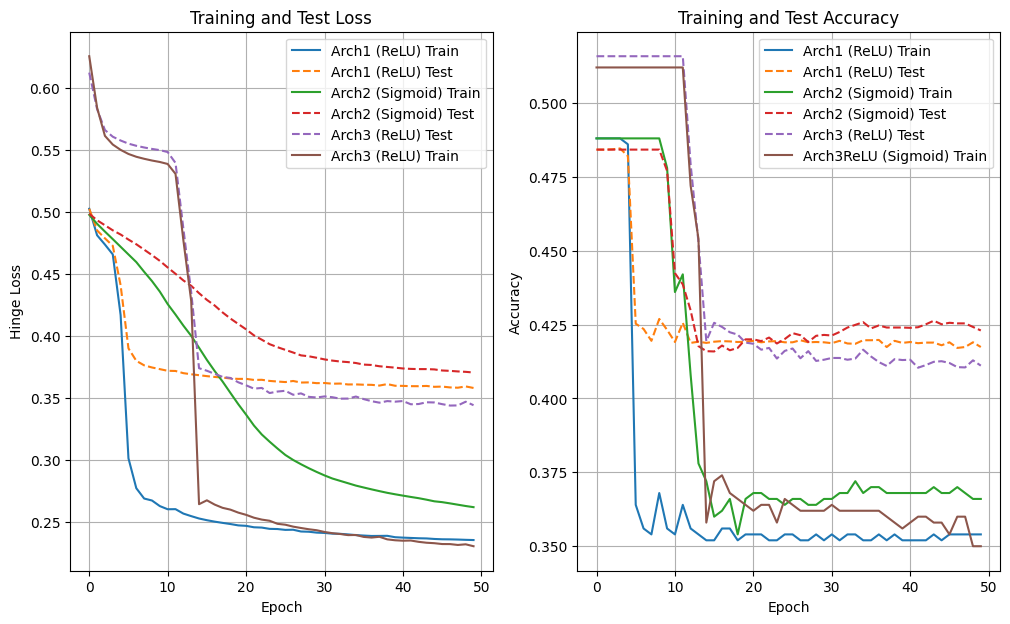

In [24]:
# Result visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    
axes[0].plot(train_loss1, label='Arch1 (ReLU) Train')
axes[0].plot(test_loss1, label='Arch1 (ReLU) Test', linestyle='--')
axes[0].plot(train_loss2, label='Arch2 (Sigmoid) Train')
axes[0].plot(test_loss2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[0].plot(test_loss3, label='Arch3 (ReLU) Test', linestyle='--')
axes[0].plot(train_loss3, label='Arch3 (ReLU) Train')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Hinge Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(train_acc1, label='Arch1 (ReLU) Train')
axes[1].plot(test_acc1, label='Arch1 (ReLU) Test', linestyle='--')
axes[1].plot(train_acc2, label='Arch2 (Sigmoid) Train')
axes[1].plot(test_acc2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[1].plot(test_acc3, label='Arch3 (ReLU) Test', linestyle='--')
axes[1].plot(train_acc3, label='Arch3ReLU (Sigmoid) Train')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

We can observe that architectures 1,3 perform better than the second one. It is true for both training and testing sets. This may occure as in architecture 2 there is activation function sigmoid comparing to ReLU in other architectures.

As for custom implememtation VS Pytorch library implementation, there is also a significant difference. We can observe that for our own implementation Loss function values for finite difference optimisation is bigger that with Pytorch (0.85-0.9 vs 0.35-0.4 for testing set loss). However, the accuracy results is better for custom implememtation.
This may accure due to threshold parametr in Pytorch. Moreover, finite difference method might be more sustainable.